# **Zomato Restaurant Data Analysis using Python**

***Part 1 — Data Understanding & Exploration***

In [3]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
data = pd.read_csv("/content/test_zomato.csv")

In [8]:
# Sample data
data.head()

,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9552 entries, 0 to 9551
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9552 non-null   object 
 1   Restaurant ID         9552 non-null   object 
 2   Restaurant Name       9552 non-null   object 
 3   Country Code          9552 non-null   float64
 4   City                  9552 non-null   object 
 5   Address               9552 non-null   object 
 6   Locality              9551 non-null   object 
 7   Locality Verbose      9551 non-null   object 
 8   Longitude             9551 non-null   object 
 9   Latitude              9551 non-null   object 
 10  Cuisines              9542 non-null   object 
 11  Average Cost for two  9551 non-null   object 
 12  Currency              9551 non-null   object 
 13  Has Table booking     9551 non-null   object 
 14  Has Online delivery   9551 non-null   object 
 15  Is delivering now    

In [10]:
# a. Shape of the dataset
print("Shape of the dataset:", data.shape)


Shape of the dataset: (9552, 22)


In [11]:
# b. Column names
print("\nColumn names:\n", data.columns)


Column names:
 Index(['Unnamed: 0', 'Restaurant ID', 'Restaurant Name', 'Country Code',
       'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude',
       'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')


In [12]:
# c. Data types
print("\nData types:\n", data.dtypes)


Data types:
 Unnamed: 0               object
Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two     object
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             float64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                   float64
dtype: object


In [17]:
# d. Missing values
print("\nMissing values per column:\n", data.isna().sum())


Missing values per column:
 Unnamed: 0               0
Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 1
Locality Verbose         1
Longitude                1
Latitude                 1
Cuisines                10
Average Cost for two     2
Currency                 1
Has Table booking        1
Has Online delivery      1
Is delivering now        1
Switch to order menu     1
Price range              2
Aggregate rating         2
Rating color             2
Rating text              2
Votes                    2
dtype: int64


In [14]:
duplicates_count = data.duplicated().sum()
print(f"Number of duplicate records: {duplicates_count}")


Number of duplicate records: 0


In [16]:
# Cleaning and converting 'Average Cost for two' to numeric
if data['Average Cost for two'].dtype == 'object':
    data['Average Cost for two'] = data['Average Cost for two'].str.replace(r'[^\d.]', '', regex=True)
    data['Average Cost for two'] = pd.to_numeric(data['Average Cost for two'], errors='coerce')

print(data['Average Cost for two'].dtype)

float64


In [18]:
#Handling missing Values
data['Average Cost for two'].fillna(data['Average Cost for two'].mean(),inplace=True)
data['Price range'].fillna(data['Price range'].mean(),inplace=True)
data['Aggregate rating'].fillna(data['Aggregate rating'].mean(),inplace=True)
data['Votes'].fillna(data['Votes'].mean(),inplace=True)

/tmp/ipykernel_1258/1427107199.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Average Cost for two'].fillna(data['Average Cost for two'].mean(),inplace=True)
/tmp/ipykernel_1258/1427107199.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

In [20]:
#Checking handles null or missing values
data.isna().sum()

,0
Unnamed: 0,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,1
Locality Verbose,1
Longitude,1
Latitude,1


In [36]:
#handling Invalid rows
import csv

misaligned_line_numbers = []

# Open the raw CSV and check field counts line by line
with open('/content/test_zomato.csv', mode='r', encoding='utf-8', errors='ignore') as f:
    reader = csv.reader(f)
    header = next(reader)
    expected_length = len(header)

    for row_idx, row in enumerate(reader, start=2): # start=2 accounting for header
        if len(row) != expected_length:
            print(f"Row {row_idx} has {len(row)} columns instead of expected {expected_length}")
            misaligned_line_numbers.append(row_idx)

Row 474 has 6 columns instead of expected 22
Row 475 has 17 columns instead of expected 22


In [39]:
# Convert raw CSV line numbers to Pandas DataFrame indices
# (Line 2 in CSV corresponds to DataFrame index 0)
pandas_indices = [line_num - 2 for line_num in misaligned_line_numbers]

# Drop the misaligned rows
data = data.drop(index=pandas_indices).reset_index(drop=True)

print(f"Successfully removed {len(pandas_indices)} misaligned row(s). New dataset shape: {data.shape}")

Successfully removed 2 misaligned row(s). New dataset shape: (9550, 22)


In [40]:
# Summary statistics
data.describe()

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9550.000000,9550.000000,9550.000000,9550.000000,9550.000000
mean,18.348272,1199.326387,1.804607,2.666314,156.923037
std,56.728197,16122.023220,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


In [23]:
# a. How many unique cities are present in the dataset?
unique_cities_count = data['City'].nunique()
print(f"a. Number of unique cities: {unique_cities_count}")

a. Number of unique cities: 142


In [24]:
# b. Which city has the highest number of restaurants?
top_city = data['City'].value_counts().idxmax()
top_city_count = data['City'].value_counts().max()
print(f"b. City with the highest number of restaurants: {top_city} ({top_city_count} restaurants)")

b. City with the highest number of restaurants: New Delhi (5473 restaurants)


In [25]:
# c. Which cuisine appears most frequently?
top_cuisine = data['Cuisines'].value_counts().idxmax()
print(f"c. Most frequently appearing cuisine combination: {top_cuisine}")

c. Most frequently appearing cuisine combination: North Indian


***Part 2 — Data Analysis***

In [26]:
avg_rating = data['Aggregate rating'].mean()
print(f"Average Restaurant Rating: {avg_rating:.2f}")

Average Restaurant Rating: 2.67


In [27]:
max_votes_index = data['Votes'].idxmax()
top_restaurant = data.loc[max_votes_index, 'Restaurant Name']
max_votes_count = data.loc[max_votes_index, 'Votes']

print(f"Restaurant with the highest votes: {top_restaurant} ({max_votes_count} votes)")

Restaurant with the highest votes: Toit (10934.0 votes)


In [28]:
avg_cost_two = data['Average Cost for two'].mean()
print(f"Average Cost for Two: {avg_cost_two:.2f}")

Average Cost for Two: 1199.33


In [42]:
online_delivery_rating = data.groupby('Has Online delivery')['Aggregate rating'].mean()
print("Average Ratings by Online Delivery Status:")
print(online_delivery_rating)

Average Ratings by Online Delivery Status:
Has Online delivery
No     2.465192
Yes    3.248837
Name: Aggregate rating, dtype: float64


In [43]:
table_booking_rating = data.groupby('Has Table booking')['Aggregate rating'].mean()
print("Average Ratings by Table Booking Status:")
print(table_booking_rating)

Average Ratings by Table Booking Status:
Has Table booking
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64


In [31]:
top_10_cities = data['City'].value_counts().head(10)
print("Top 10 Cities with the Highest Number of Restaurants:")
print(top_10_cities)

Top 10 Cities with the Highest Number of Restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [41]:
# Get distinct values in 'Has Online delivery'
online_delivery_values = data['Has Online delivery'].unique()
print("Distinct values in 'Has Online delivery':", online_delivery_values)

# Get value counts for 'Has Online delivery' to see the distribution
print("\nValue counts for 'Has Online delivery':")
print(data['Has Online delivery'].value_counts())

# Get distinct values in 'Has Table booking'
table_booking_values = data['Has Table booking'].unique()
print("\nDistinct values in 'Has Table booking':", table_booking_values)

# Get value counts for 'Has Table booking' to see the distribution
print("\nValue counts for 'Has Table booking':")
print(data['Has Table booking'].value_counts())

Distinct values in 'Has Online delivery': ['No' 'Yes']

Value counts for 'Has Online delivery':
Has Online delivery
No     7099
Yes    2451
Name: count, dtype: int64

Distinct values in 'Has Table booking': ['Yes' 'No']

Value counts for 'Has Table booking':
Has Table booking
No     8392
Yes    1158
Name: count, dtype: int64


***Part 3 — Data Visualization***

/tmp/ipykernel_1258/3517476602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_r")


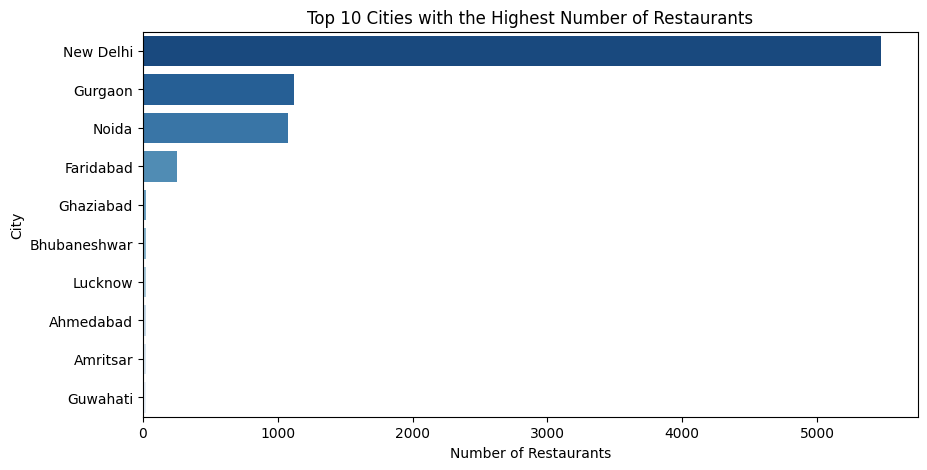

In [44]:
plt.figure(figsize=(10, 5))
top_cities = data['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_r")
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.title('Top 10 Cities with the Highest Number of Restaurants')
plt.show()

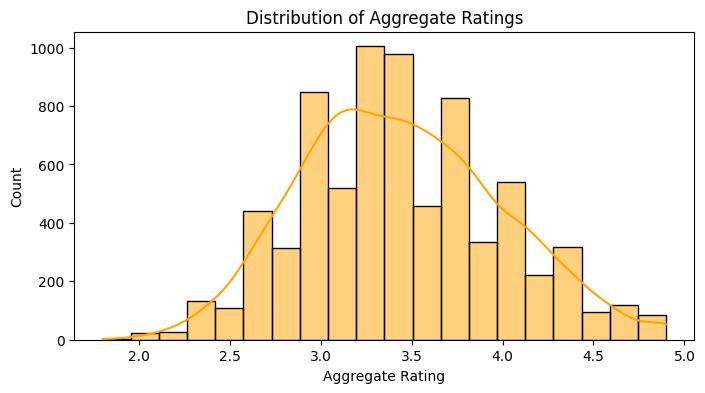

In [45]:
plt.figure(figsize=(8, 4))
# Filtering out 0.0 ratings if they represent unrated entries to see an accurate distribution
filtered_ratings = data[data['Aggregate rating'] > 0]['Aggregate rating']
sns.histplot(filtered_ratings, bins=20, kde=True, color='orange')
plt.xlabel('Aggregate Rating')
plt.ylabel('Count')
plt.title('Distribution of Aggregate Ratings')
plt.show()

/tmp/ipykernel_1258/2951657966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_counts.index, y=delivery_counts.values, palette="Set2")


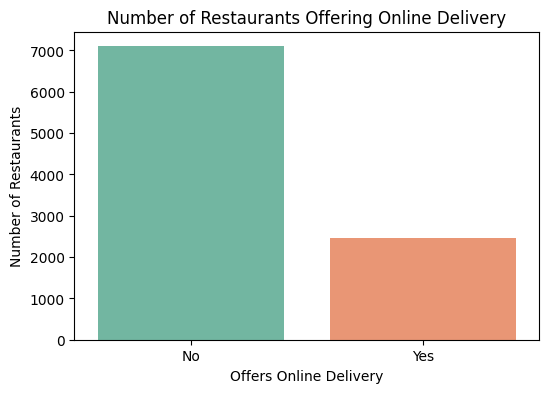

In [55]:
plt.figure(figsize=(6, 4))
# Checking variation in column names based on common Zomato formats
delivery_col = 'Has Online delivery' if 'Has Online delivery' in data.columns else 'online_order'
delivery_counts = data[delivery_col].value_counts()
sns.barplot(x=delivery_counts.index, y=delivery_counts.values, palette="Set2")
plt.xlabel('Offers Online Delivery')
plt.ylabel('Number of Restaurants')
plt.title('Number of Restaurants Offering Online Delivery')
plt.show()

/tmp/ipykernel_1258/2034472950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="magma")


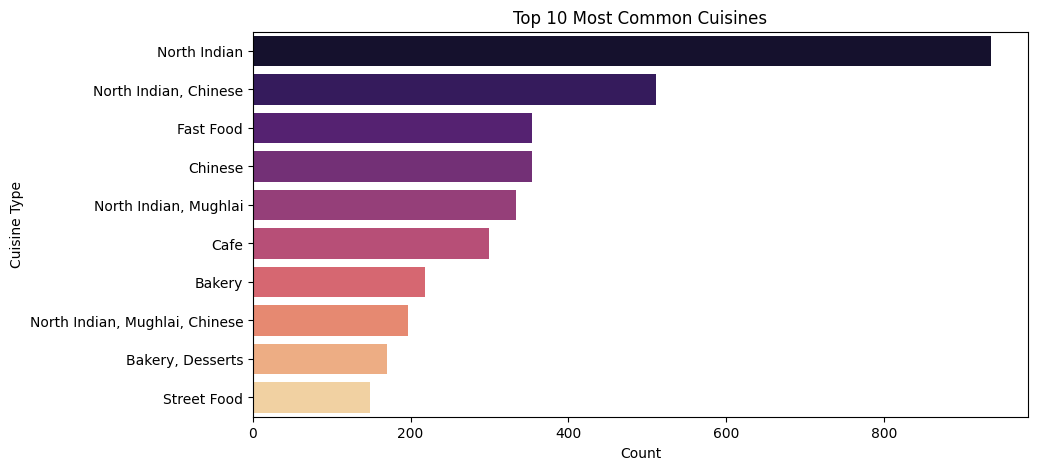

In [56]:
plt.figure(figsize=(10, 5))
# Zomato rows often list multiple cuisines separated by commas; this extracts individual counts
split_cuisines = data['Cuisines']
top_cuisines = split_cuisines.value_counts().head(10)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="magma")
plt.xlabel('Count')
plt.ylabel('Cuisine Type')
plt.title('Top 10 Most Common Cuisines')
plt.show()

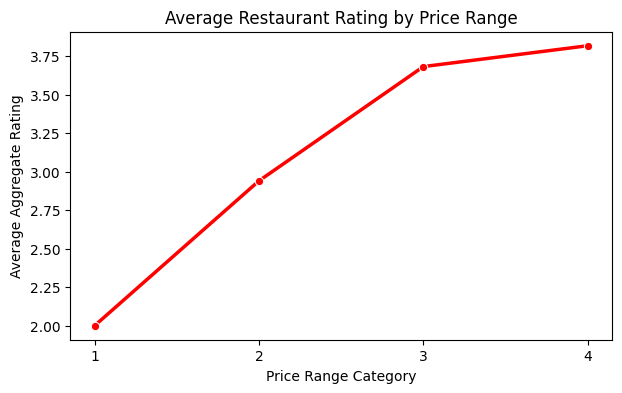

In [57]:
plt.figure(figsize=(7, 4))
price_col = 'Price range' if 'Price range' in data.columns else 'approx_cost(for two people)'

# Group data to calculate the average rating for each unique price category
avg_rating_by_price = data.groupby(price_col)['Aggregate rating'].mean().reset_index()

sns.lineplot(x=price_col, y='Aggregate rating', data=avg_rating_by_price, marker='o', color='red', linewidth=2.5)
plt.xlabel('Price Range Category')
plt.ylabel('Average Aggregate Rating')
plt.title('Average Restaurant Rating by Price Range')
plt.xticks(avg_rating_by_price[price_col].unique())
plt.show()

***Part 4 — Insights & Conclusion***

1. Which city has the highest restaurant presence? - Delhi
2. What is the most popular cuisine? - North Indian
3. Do restaurants with Online Delivery generally have higher ratings? - Yes
4. Do restaurants offering Table Booking receive better ratings? - Yes
5. What did you learn from analyzing this dataset? - Data analysis is an aeffective tool to interpret business Insights.